# 📊 **Dataset Overview**

This project explores a comprehensive dataset containing detailed information about social media advertisement performance across multiple platforms. The dataset includes:
1. Users: Demographic and behavioral data of individuals interacting with ads.
2. Ads: Metadata about each advertisement, including format, platform, and targeting.
3. Campaigns: Groupings of ads under strategic marketing initiatives.
4. Ad Events: Real-time interactions such as impressions, clicks, and conversions.



#### 🎯**Objective**
The goal is to build a unified analytical view by merging these diverse data sources, enabling robust insights into:


* Customer satisfaction trends based on ad engagement.
*  Campaign effectiveness across platforms and demographics.


#### Reading the Data

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/social-media-advertisement-performance/users.csv
/kaggle/input/social-media-advertisement-performance/ad_campaign_db.sqlite
/kaggle/input/social-media-advertisement-performance/ads.csv
/kaggle/input/social-media-advertisement-performance/campaigns.csv
/kaggle/input/social-media-advertisement-performance/ad_events.csv


In [2]:
# Load CSV files
ads = pd.read_csv('/kaggle/input/social-media-advertisement-performance/ads.csv')
campaigns = pd.read_csv('/kaggle/input/social-media-advertisement-performance/campaigns.csv')
ad_events = pd.read_csv('/kaggle/input/social-media-advertisement-performance/ad_events.csv')
users = pd.read_csv('/kaggle/input/social-media-advertisement-performance/users.csv')
"""
# Preview each dataset
print("Ads:")
print(ads.head())

print("\nCampaigns:")
print(campaigns.head())

print("\nAd Events:")
print(ad_events.head())

print("\nUsers:")
print(users.head())
"""

'\n# Preview each dataset\nprint("Ads:")\nprint(ads.head())\n\nprint("\nCampaigns:")\nprint(campaigns.head())\n\nprint("\nAd Events:")\nprint(ad_events.head())\n\nprint("\nUsers:")\nprint(users.head())\n'

In [3]:
#Define the full dataset
ads_campaign= pd.merge(ads, campaigns, on= "campaign_id",how="outer")
ads_campaigns_event= pd.merge(ads_campaign,ad_events, on="ad_id",how="outer")
full_df= pd.merge(ads_campaigns_event,users,on="user_id",how="outer")
full_df["user_gender"]=full_df["user_gender"].replace("Other","All")
full_df["age_group"]=full_df["age_group"].replace({'16-17':'All', '45-54':'All','55-65':'All'})

# Missing Value Imputation

In [4]:
# Define critical columns for engagement and satisfaction analysis
critical_columns = ['ad_id', 'campaign_id', 'event_id','user_id']

# Check initial shape
initial_shape = full_df.shape

# Drop rows with missing values in any critical column
full_df_cleaned = full_df.dropna(subset=critical_columns)

# Check final shape
final_shape = full_df_cleaned.shape
rows_dropped = initial_shape[0] - final_shape[0]

# Report
print(f"Dropped {rows_dropped} rows with missing values in critical columns.")
print(f"Remaining rows: {final_shape[0]}")


Dropped 2 rows with missing values in critical columns.
Remaining rows: 403967


In [5]:
# Check missing values
missing_summary = full_df_cleaned.isnull().sum()
total_missing = missing_summary.sum()

# Report missing values
if total_missing == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values per column:")
    print(missing_summary[missing_summary > 0])

    # Impute missing values based on column type
    for column in full_df_cleaned.columns:
        if full_df_cleaned[column].isnull().any():
            if full_df_cleaned[column].dtype in ['float64', 'int64']:
                median_value = full_df_cleaned[column].median()
                full_df_cleaned[column].fillna(median_value, inplace=True)
                print(f"Imputed missing values in numerical column '{column}' with median: {median_value}")
            elif full_df_cleaned[column].dtype == 'object':
                mode_value = full_df_cleaned[column].mode()[0]
                full_df_cleaned[column].fillna(mode_value, inplace=True)
                print(f"Imputed missing values in categorical column '{column}' with mode: {mode_value}")

    #Confirm missing values are handled
    print("\n Missing values after imputation:")
    print(full_df_cleaned.isnull().sum())


No missing values found in the dataset.


# Exploratry Data Analysis (EDA)

In [6]:
for i in full_df_cleaned.columns:
    if full_df_cleaned[i].dtype == "object" and len(full_df_cleaned[i].unique())<15:
        print(f"Column {i} Unique value: {full_df_cleaned[i].unique()}")

Column ad_platform Unique value: ['Facebook' 'Instagram']
Column ad_type Unique value: ['Stories' 'Image' 'Video' 'Carousel']
Column target_gender Unique value: ['All' 'Male' 'Female']
Column target_age_group Unique value: ['25-34' 'All' '35-44' '18-24']
Column day_of_week Unique value: ['Monday' 'Tuesday' 'Friday' 'Wednesday' 'Thursday' 'Saturday' 'Sunday']
Column time_of_day Unique value: ['Evening' 'Morning' 'Afternoon' 'Night']
Column event_type Unique value: ['Click' 'Impression' 'Like' 'Comment' 'Purchase' 'Share']
Column user_gender Unique value: ['Female' 'Male' 'All']
Column age_group Unique value: ['All' '35-44' '25-34' '18-24']
Column country Unique value: ['France' 'United States' 'United Kingdom' 'India' 'Canada' 'Mexico'
 'Australia' 'Brazil' 'Germany' 'Japan']


#### Visualization - Event type distribution by country,age group,user gender,ad_platform and ad type

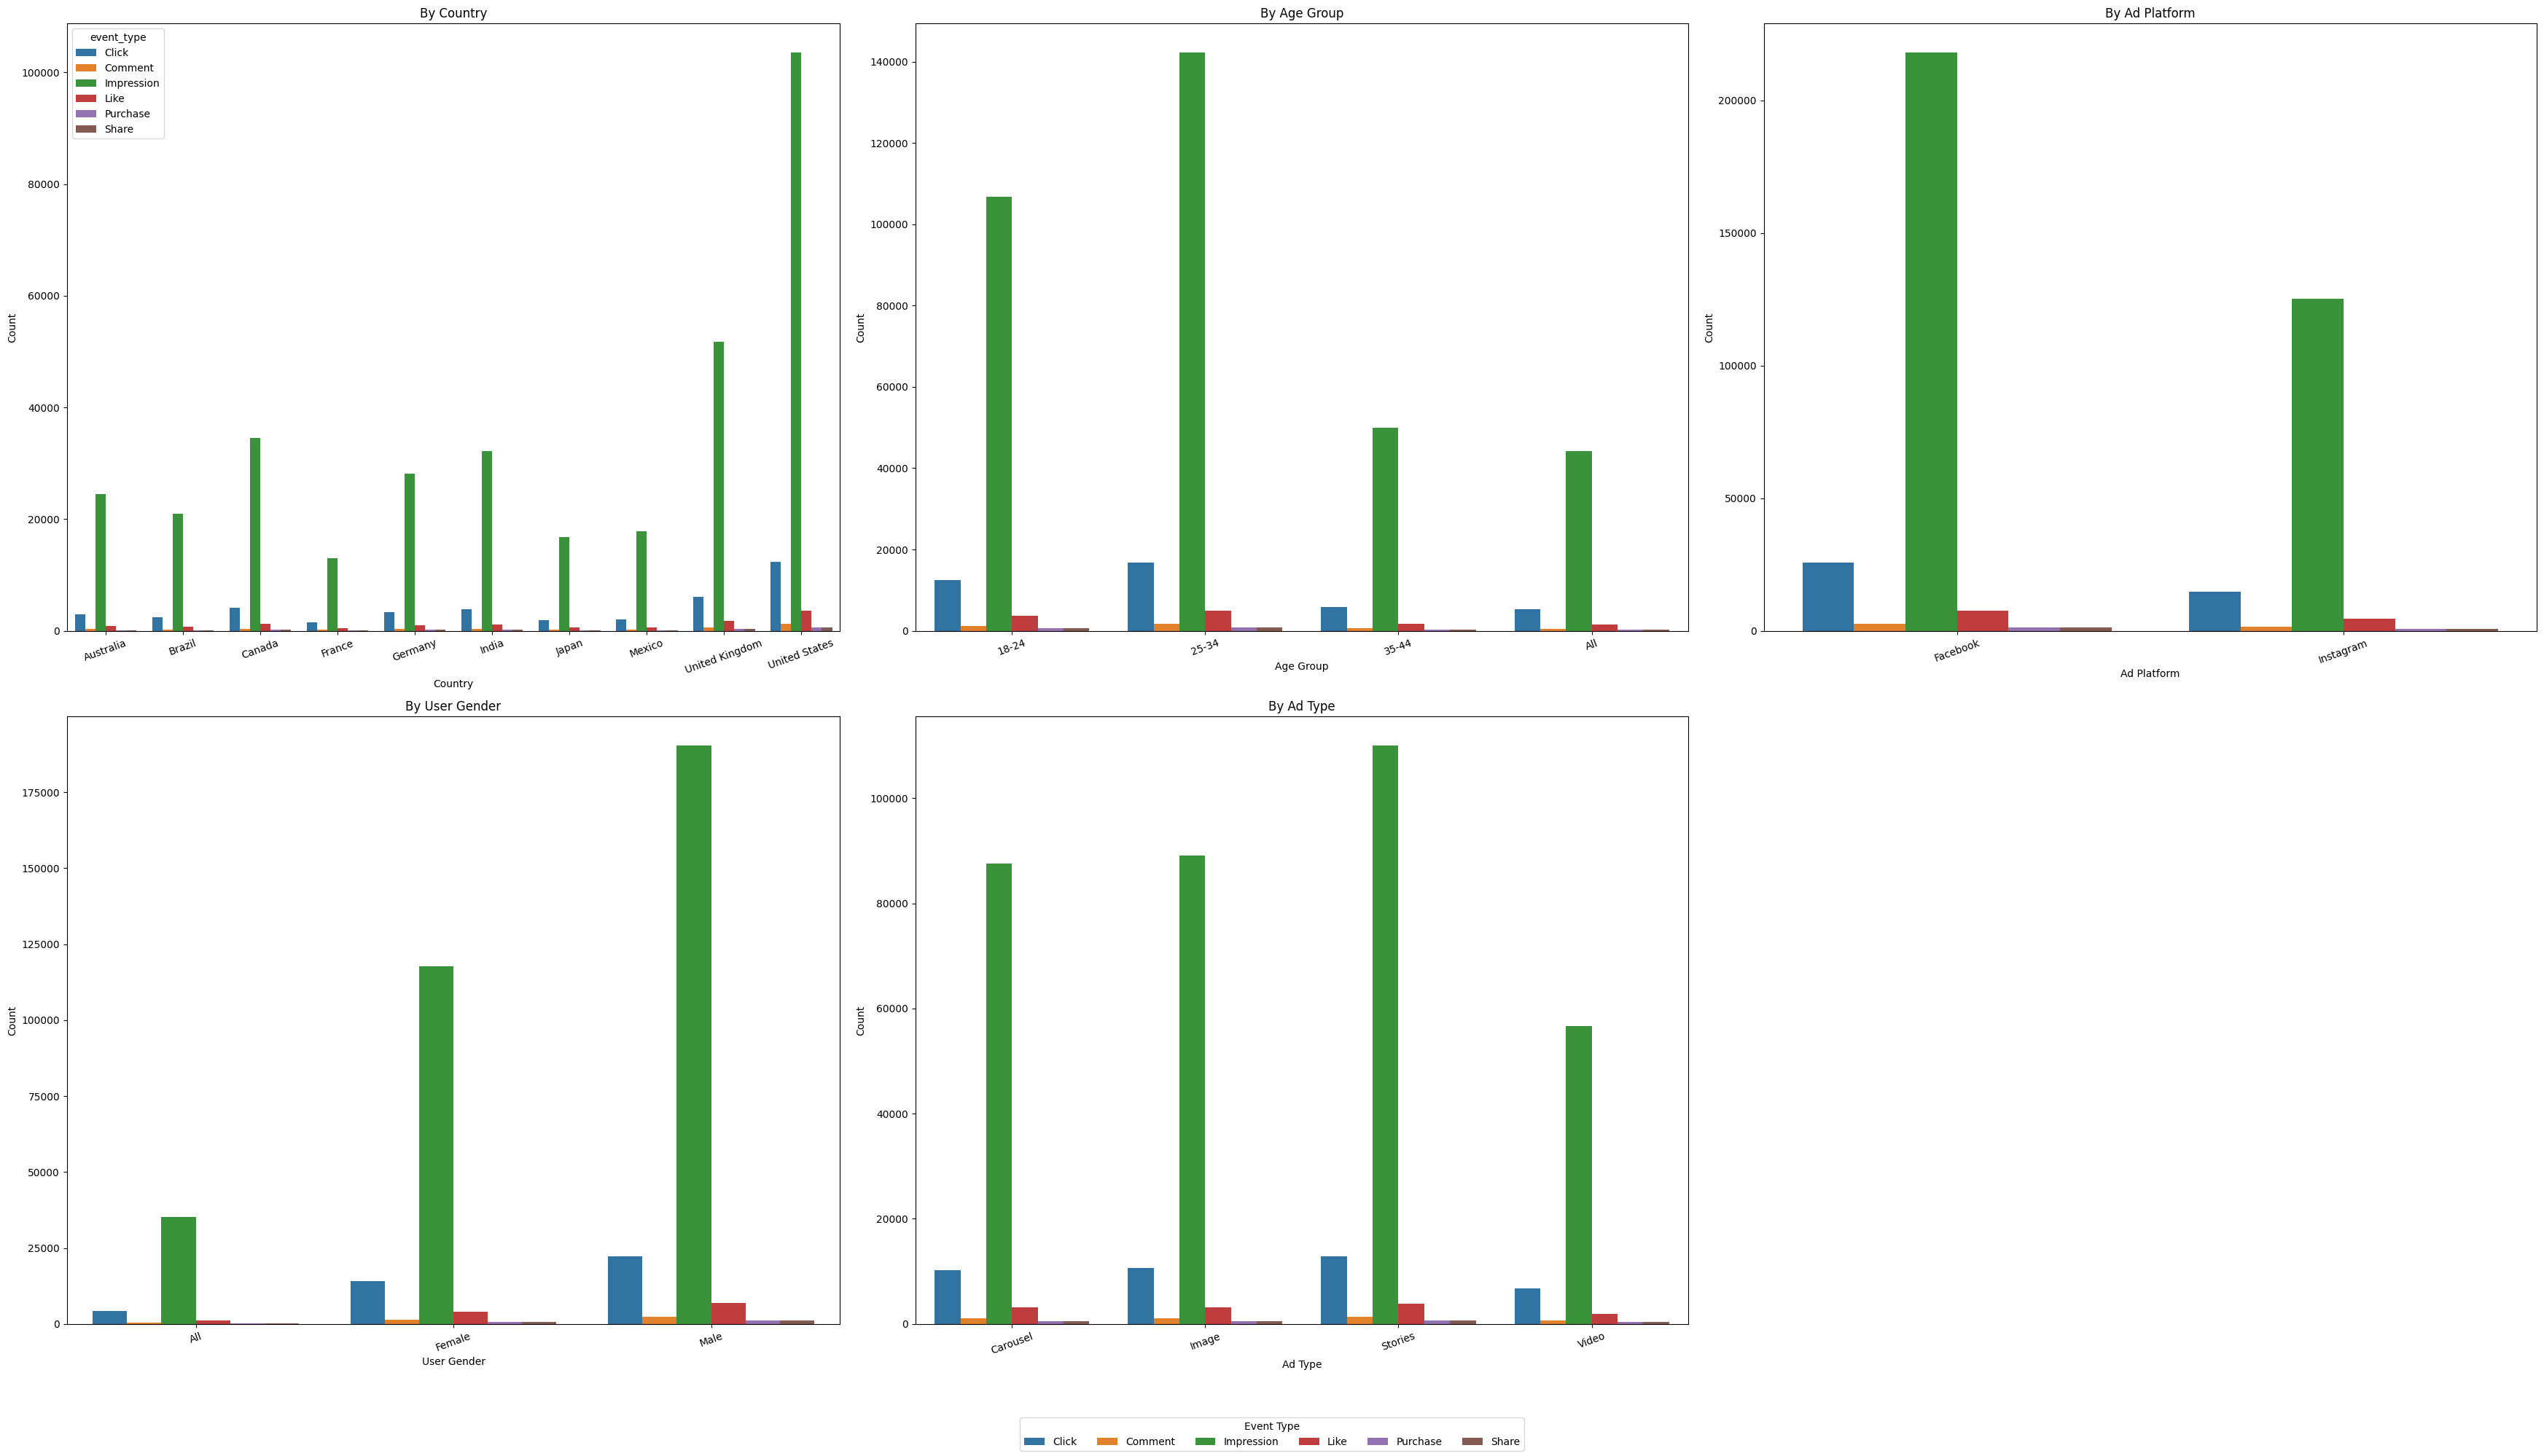

In [7]:
import pandas as pd                 # Import pandas for data manipulation
import matplotlib.pyplot as plt     # Import matplotlib for plotting
import seaborn as sns               # Import seaborn for easier, prettier plots

# Step 1: Create pivot table (counts of rows per combination of index + event_type)
pivot_table = pd.pivot_table(
    full_df_cleaned,                                   # The cleaned source dataframe
    index=['country','age_group','user_gender',        # Grouping keys (dimensions)
           'ad_platform','ad_type'],
    columns='event_type',                              # Make each event type a separate column
    aggfunc='size',                                    # Count rows per group (like .size())
    fill_value=0                                       # Fill missing combinations with 0
).reset_index()                                        # Convert index back to columns for easy use

# Step 2: Melt pivoted data back to long format for plotting
melted_df = pivot_table.melt(
    id_vars=['country','age_group','user_gender',      # Keep these as identifier columns
             'ad_platform','ad_type'],
    var_name='event_type',                             # New column name for former wide columns
    value_name='count'                                 # New column name for the aggregated counts
)

# Step 3: Choose which dimensions (x-axes) to visualize
dimensions = ['country', 'age_group', 'ad_platform', 
              'user_gender', 'ad_type']  # 5 panels total

# Step 4: Create a 2x3 grid of subplots (we'll use 5 and hide the last empty one)
fig, axes = plt.subplots(2, 3, figsize=(35, 20))       # 2 rows × 3 columns, overall figure size
axes = axes.flatten()                                  # Flatten 2D axes to a 1D list for easy indexing

# Step 5: Loop over each dimension and plot a bar chart
for i, dim in enumerate(dimensions):                   # i is index, dim is the column name (e.g., 'country')
    g = melted_df.groupby([dim, 'event_type'],         
                          as_index=False)['count'].sum()
    
    # Draw the barplot for this dimension
    sns.barplot(
        data=g,                                        # Use the aggregated data
        x=dim,                                         # Current dimension on x-axis
        y='count',                                     # Total count on y-axis
        hue='event_type',                              # Different colors per event type
        ax=axes[i]                                     # Plot on the i-th subplot
        
    )
    
    # Title and axis labels for the subplot
    axes[i].set_title(f'By {dim.replace("_", " ").title()}')  # formatted panel title
    axes[i].set_xlabel(dim.replace("_", " ").title())         # formatted x-axis label
    axes[i].set_ylabel('Count')                               # y-axis label
    
    # Make x labels readable by rotating a bit
    axes[i].tick_params(axis='x', rotation=20)                # Slight rotation to prevent overlap
    
    # Remove legend from all subplots except the first one (to save space)
    if i != 0:
        axes[i].get_legend().remove()

# Step 6: Add one shared legend for the entire figure (uses handles from the first plot)
handles, labels = axes[0].get_legend_handles_labels()         # Get legend items from first axis
fig.legend(handles, labels,                                   # Put a single shared legend
           loc='lower center',                                 # Place at the bottom center
           ncol=len(labels),                                   # Spread across columns
           title='Event Type')                                 # Legend title

# Step 7: Hide the unused 6th
axes[-1].axis('off') # Turn off the last empty panels


# Step 8: Adjust layout so subplots fit well and leave space for the legend
plt.tight_layout(rect=[0, 0.05, 1, 1])                        # Shrink plot area a bit at bottom for legend

# Step 9: Render the final figure on screen
plt.show()                                                    # Display the figure


### **Interpretation:**
* Impressions are the dominant event type across all dimensions, indicating strong ad visibility.
* 25–34 age group, Facebook, and Stories ads are the top-performing segments.
* These insights can guide ad format selection, platform prioritization, and audience targeting.


#### Visualization - Ad Platform distribution by country,age group,user gender,Event type and ad type

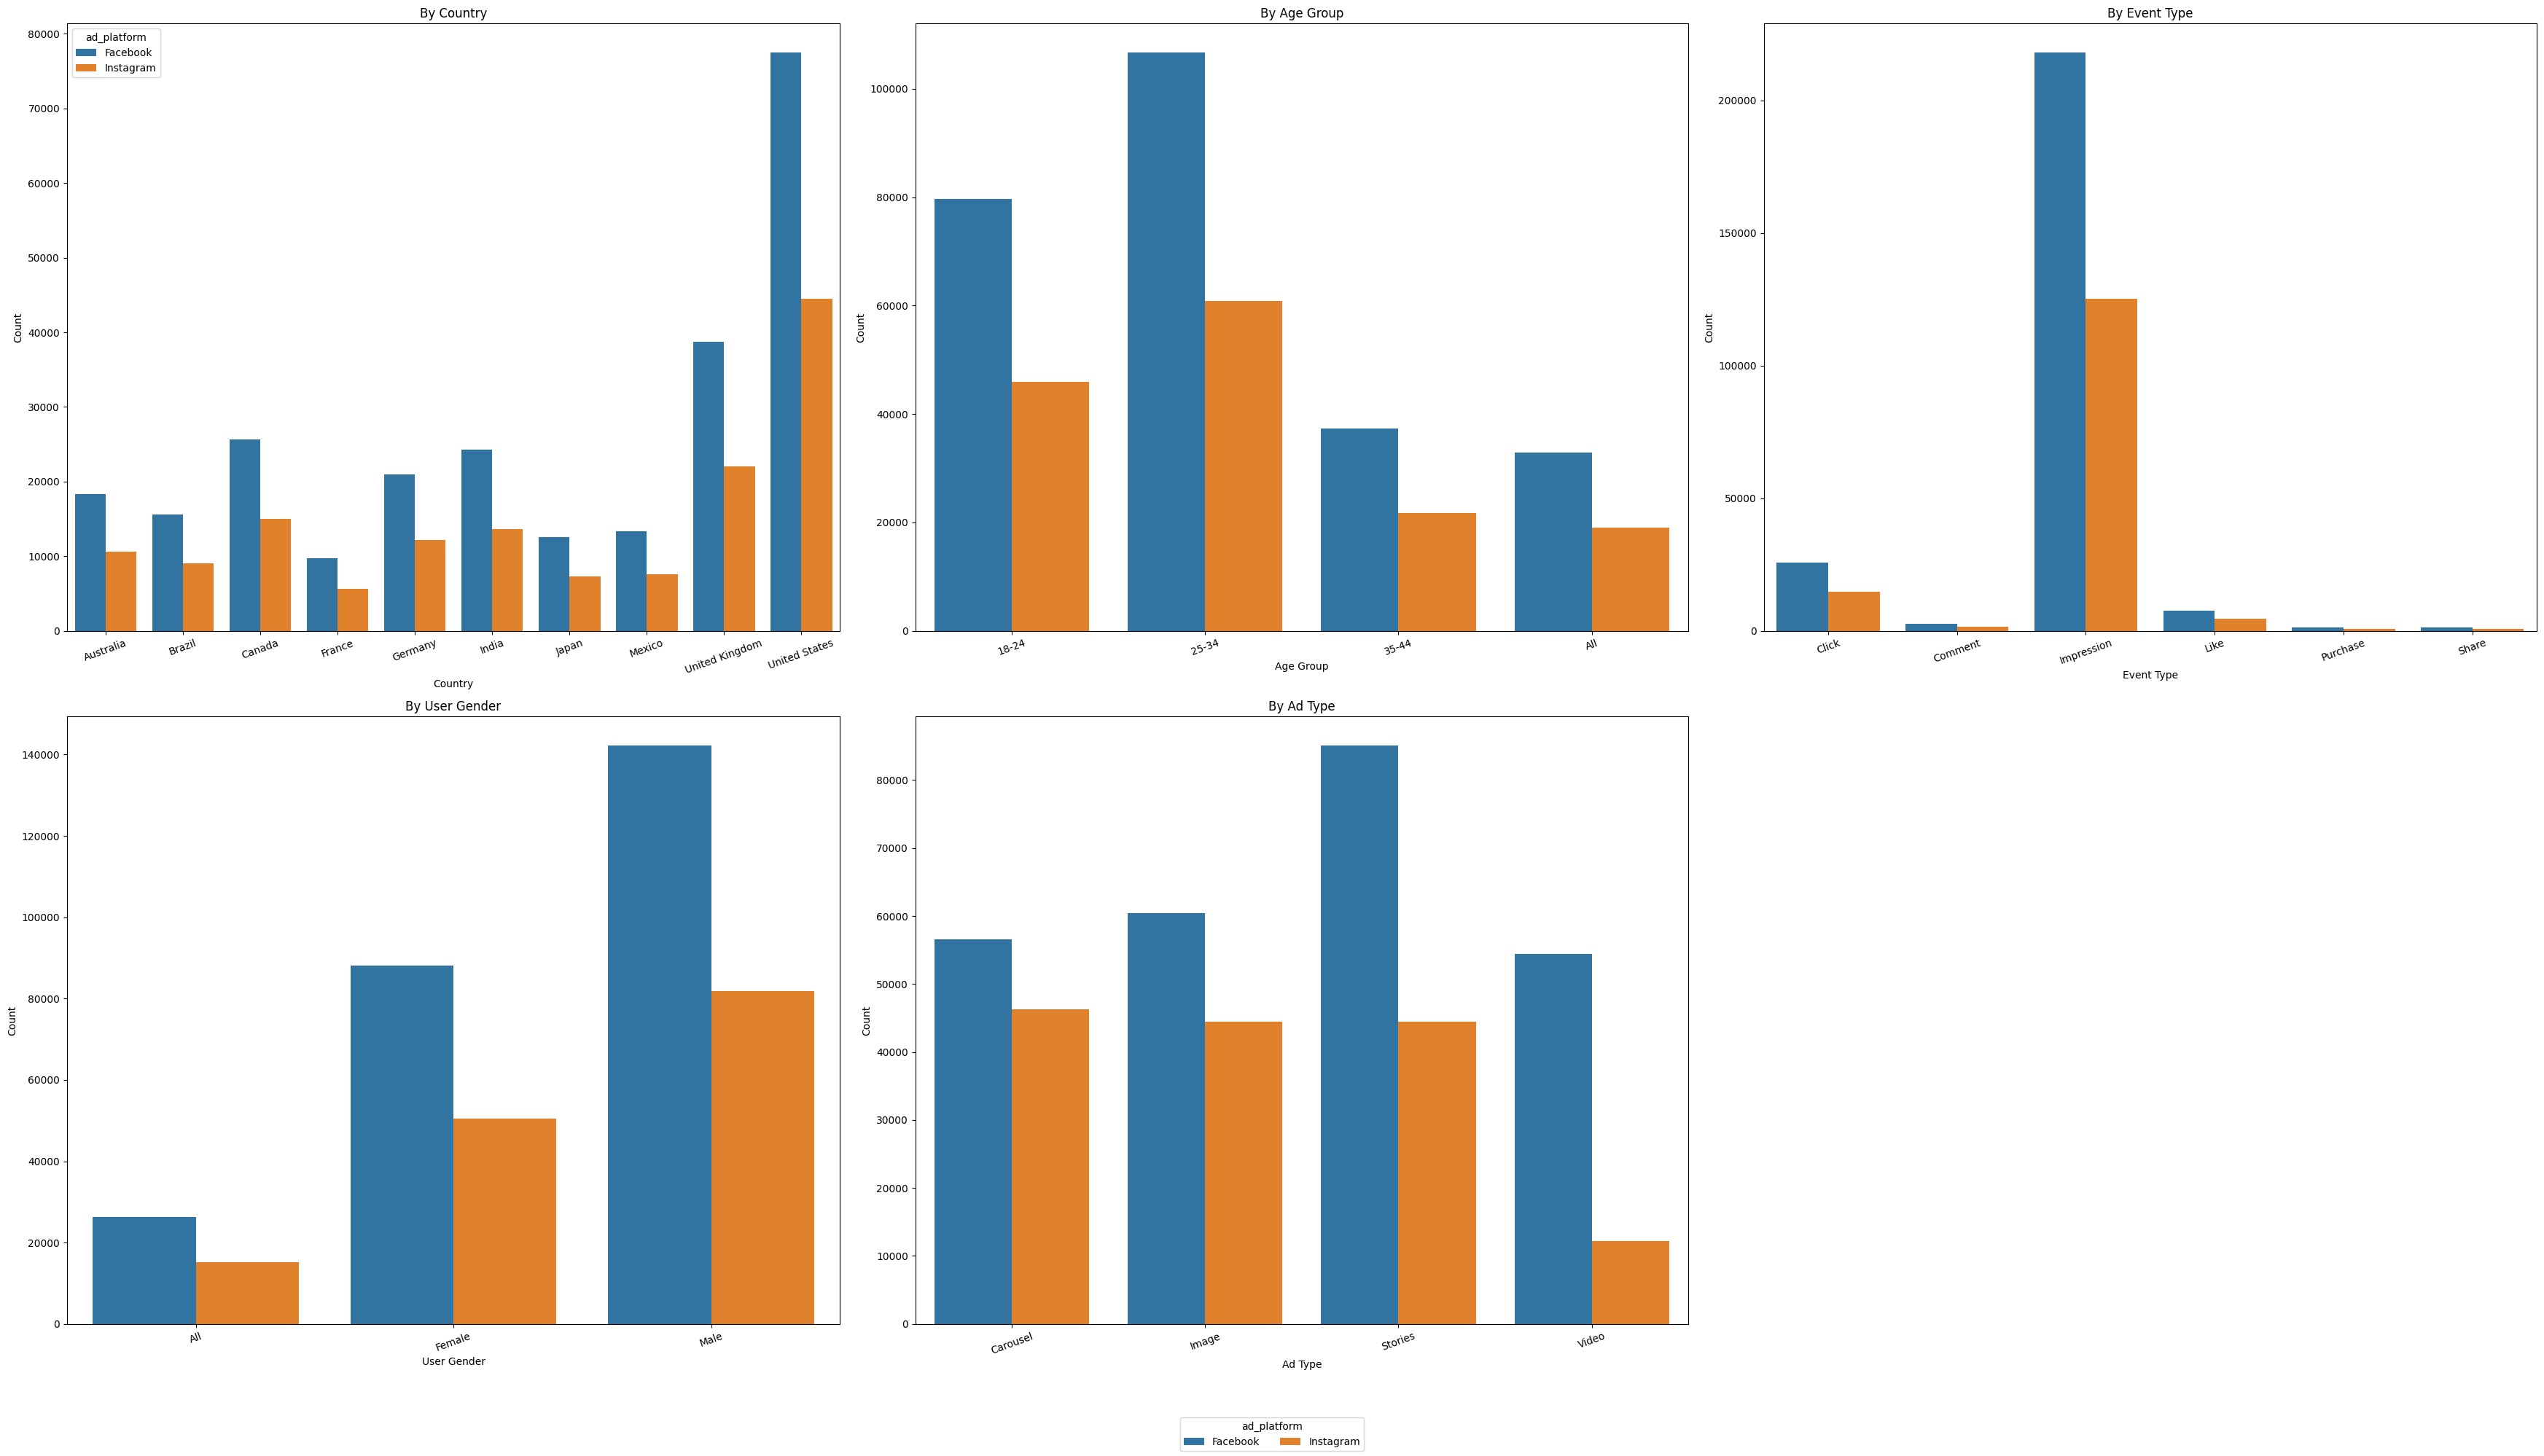

In [8]:
import pandas as pd                 # Import pandas for data manipulation
import matplotlib.pyplot as plt     # Import matplotlib for plotting
import seaborn as sns               # Import seaborn for easier, prettier plots

# Step 1: Create pivot table (counts of rows per combination of index + ad platform)
pivot_table = pd.pivot_table(
    full_df_cleaned,                                   # The cleaned source dataframe
    index=['country','age_group','user_gender',        # Grouping keys (dimensions)
           'event_type','ad_type'],
    columns='ad_platform',                              # Make each event type a separate column
    aggfunc='size',                                    # Count rows per group (like .size())
    fill_value=0                                       # Fill missing combinations with 0
).reset_index()                                        # Convert index back to columns for easy use

# Step 2: Melt pivoted data back to long format for plotting
melted_df = pivot_table.melt(
    id_vars=['country','age_group','user_gender',      # Keep these as identifier columns
             'event_type','ad_type'],
    var_name='ad_platform',                             # New column name for former wide columns
    value_name='count'                                 # New column name for the aggregated counts
)

# Step 3: Choose which dimensions (x-axes) to visualize
dimensions = ['country', 'age_group', 'event_type', 
              'user_gender', 'ad_type']  # 5 panels total

# Step 4: Create a 2x3 grid of subplots (we'll use 5 and hide the last empty)
fig, axes = plt.subplots(2, 3, figsize=(35, 20))       # 2 rows × 3 columns, overall figure size
axes = axes.flatten()                                  # Flatten 2D axes to a 1D list for easy indexing

# Step 5: Loop over each dimension and plot a bar chart
for i, dim in enumerate(dimensions):                   # i is index, dim is the column name (e.g., 'country')
    g = melted_df.groupby([dim, 'ad_platform'],        
                          as_index=False)['count'].sum()
    
    # Draw the barplot for this dimension
    sns.barplot(
        data=g,                                        # Use the aggregated data
        x=dim,                                         # Current dimension on x-axis
        y='count',                                     # Total count on y-axis
        hue='ad_platform',                              # Different colors per event type
        ax=axes[i]                                     # Plot on the i-th subplot
        
    )
    
    # Title and axis labels for the subplot
    axes[i].set_title(f'By {dim.replace("_", " ").title()}')  # formatted panel title
    axes[i].set_xlabel(dim.replace("_", " ").title())         # formatted x-axis label
    axes[i].set_ylabel('Count')                               # y-axis label
    
    # Make x labels readable by rotating a bit
    axes[i].tick_params(axis='x', rotation=20)                # Slight rotation to prevent overlap
    
    # Remove legend from all subplots except the first one (to save space)
    if i != 0:
        axes[i].get_legend().remove()

# Step 6: Add one shared legend for the entire figure (uses handles from the first plot)
handles, labels = axes[0].get_legend_handles_labels()         # Get legend items from first axis  
fig.legend(handles, labels,                                   # Put a single shared legend
           loc='lower center',                                 # Place at the bottom center
           ncol=len(labels),                                   # Spread across columns
           title='ad_platform')                                 # Legend title

# Step 7: Hide the unused 6th subplot 
axes[-1].axis('off') # Turn off the last empty panels


# Step 8: Adjust layout so subplots fit well and leave space for the legend
plt.tight_layout(rect=[0, 0.05, 1, 1])                        # Shrink plot area a bit at bottom for legend

# Step 9: Render the final figure on screen
plt.show() # Display the figure



### **Interpretation :**

1. Facebook consistently outperforms Instagram in total ad volume across all dimensions.
2. Instagram shows strength in younger age groups and modern ad formats (Stories).

These insights can guide platform-specific ad strategies, such as:
   

* Use Facebook for broader reach and older demographics.
* Use Instagram for younger audiences and visually engaging formats




# 🎯 Objective 1: Customer Satisfaction Trends Based on Ad Engagement

### Behavioral Event Analysis
Metrics:
count: Total number of each event type
drop_off_ratio: Ratio of each event type to impressions

Goal: Understand user behavior and satisfaction signals.

In [9]:

# Behavioral Analysis
event_counts = full_df_cleaned['event_type'].value_counts().reset_index()
event_counts.columns = ['event_type', 'count']
impressions = event_counts.loc[event_counts['event_type'] == 'Impression', 'count'].values[0]
event_counts['drop_off_ratio'] = event_counts['count'] / impressions

print("\n=== Behavioral Event Analysis ===")
print(event_counts)



=== Behavioral Event Analysis ===
   event_type   count  drop_off_ratio
0  Impression  343157        1.000000
1       Click   40495        0.118007
2        Like   12145        0.035392
3     Comment    4142        0.012070
4    Purchase    2050        0.005974
5       Share    1978        0.005764


**Conclusion:** While visibility is high, actual engagement and conversion are low. This signals a need to refine targeting and improve user experience across touchpoints.

**Target Actions:**

* Retarget Clickers with personalized offers to convert interest into purchases.
* Enhance Content Appeal to increase likes and comments—use emotional storytelling, better visuals, or influencer tie-ins.
* Streamline Purchase Flow with simpler checkout, time-sensitive discounts, and clearer product value.
* Encourage Sharing by adding referral rewards, social proof, and easy share options.


### Targeting Effectiveness
Metrics:
target_match: Boolean flag for match between targeting and actual user
engagement_rate: Proportion of matched vs unmatched interactions

Goal: Evaluate how well targeting aligns with actual engaged users.

In [10]:
# Targeting Effectiveness
target_match = (full_df_cleaned['target_gender'] == full_df_cleaned['user_gender']) & \
               (full_df_cleaned['target_age_group'] == full_df_cleaned['age_group']) 

full_df_cleaned['target_match'] = target_match
target_effectiveness = full_df_cleaned.groupby('target_match')['event_type'].count().reset_index(name='event_count')
target_effectiveness['engagement_rate'] = target_effectiveness['event_count'] / full_df_cleaned.shape[0]

print("\n=== Targeting Effectiveness ===")
print(target_effectiveness)


=== Targeting Effectiveness ===
   target_match  event_count  engagement_rate
0         False       373666         0.924991
1          True        30301         0.075009


/tmp/ipykernel_13/3001501419.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_df_cleaned['target_match'] = target_match


**Conclusion:** Current targeting strategy is highly misaligned with actual user behavior. Most engaged users are not the ones being targeted, indicating a mismatch in gender, age group, or interests.

**Target Action:**
* Re-evaluate Target Profiles: Analyze the demographics and interests of actual engaged users and update targeting criteria accordingly.
* A/B Test New Target Groups: Experiment with broader or alternative audience definitions to improve alignment.

### Temporal Patterns
Metrics:
total_events: Count of interactions by day and time

Goal: Discover peak engagement periods for ad scheduling.

In [11]:

# Temporal Patterns
temporal_engagement = full_df_cleaned.groupby(['day_of_week', 'time_of_day']).agg(
    total_events=('event_type', 'count')
).reset_index()

print("\n=== Temporal Engagement Patterns ===")
print(temporal_engagement)


=== Temporal Engagement Patterns ===
   day_of_week time_of_day  total_events
0       Friday   Afternoon         14445
1       Friday     Evening         14539
2       Friday     Morning         14470
3       Friday       Night         14510
4       Monday   Afternoon         14463
5       Monday     Evening         14430
6       Monday     Morning         14524
7       Monday       Night         14380
8     Saturday   Afternoon         14612
9     Saturday     Evening         14339
10    Saturday     Morning         14311
11    Saturday       Night         14335
12      Sunday   Afternoon         14375
13      Sunday     Evening         14352
14      Sunday     Morning         14457
15      Sunday       Night         14397
16    Thursday   Afternoon         14496
17    Thursday     Evening         14395
18    Thursday     Morning         14504
19    Thursday       Night         14336
20     Tuesday   Afternoon         14361
21     Tuesday     Evening         14568
22     Tuesday     

**Conclusion:** Engagement is evenly spread across weekdays and time slots, indicating that users are active throughout the week without strong temporal preferences.

# 🎯 Objective 2: Campaign Effectiveness Across Platforms and Demographics

### Campaign & Ad-Level Analysis
Metrics:
total_events: Number of ad interactions per ad
cost_per_event: Budget divided by total events

Goal: Identify which ads and platforms deliver the most engagement per dollar spent.

In [12]:
# Campaign & Ad-Level Analysis
campaign_metrics = full_df_cleaned.groupby(['ad_id', 'campaign_id', 'ad_platform', 'ad_type']).agg(
    total_budget=('total_budget', 'max'),
    duration_days=('duration_days', 'max'),
    total_events=('event_type', 'count')
).reset_index()
campaign_metrics['cost_per_event'] = campaign_metrics['total_budget'] / campaign_metrics['total_events']

# Display summary tables
#print("=== Campaign & Ad-Level Metrics ===")
#print(campaign_metrics.head())

# Generate readable summary using simple syntax
summary = []
for i in range(len(campaign_metrics[campaign_metrics['ad_id'].isin([1, 2])])): #Sample Output for ad id 1 and 2
    row = campaign_metrics.iloc[i]
    text = "Ad ID " + str(int(row['ad_id'])) + " in Campaign " + str(int(row['campaign_id'])) + " on " + row['ad_platform']
    text += " (" + row['ad_type'] + " ad):\n"
    text += "  - Avg Budget: $" + str(round(row['total_budget'], 2)) + "\n"
    text += "  - Avg Duration: " + str(round(row['duration_days'], 1)) + " days\n"
    text += "  - Total Events: " + str(int(row['total_events'])) + "\n"
    text += "  - Cost per Event: $" + str(round(row['cost_per_event'], 2)) + "\n"
    summary.append(text)

# Print the summary
print("=== Campaign & Ad-Level Summary ===\n")
for s in summary:
    print(s)


=== Campaign & Ad-Level Summary ===

Ad ID 1 in Campaign 28 on Facebook (Video ad):
  - Avg Budget: $32844.79
  - Avg Duration: 52 days
  - Total Events: 2066
  - Cost per Event: $15.9

Ad ID 2 in Campaign 33 on Facebook (Stories ad):
  - Avg Budget: $59264.68
  - Avg Duration: 87 days
  - Total Events: 2079
  - Cost per Event: $28.51



**Insight:** Cost per event varies widely across ad types and platforms — useful for budget optimization.

### Demographic Engagement
Metrics:
Engagement breakdown by gender, age, and geography.
Identify top-performing segments.

Goal: Understand who is engaging and where.

In [13]:
# Demographic Engagement
demographic_engagement = full_df_cleaned.groupby(['user_gender', 'age_group', 'country']).agg(
    total_events=('event_type', 'count')
).reset_index()

print("\n=== Demographic Engagement ===")
print(demographic_engagement.head())


=== Demographic Engagement ===
  user_gender age_group    country  total_events
0         All     18-24  Australia          1005
1         All     18-24     Brazil           557
2         All     18-24     Canada          1007
3         All     18-24     France           416
4         All     18-24    Germany           990


### Engagement by Ad Type and Platform

In [14]:

#Engagement by Ad Type and Platform
adtype_platform_summary = full_df_cleaned.groupby(['ad_platform', 'ad_type', 'event_type']).size().reset_index(name='count')


print("\n=== Engagement by Ad Type and Platform ===")
print(adtype_platform_summary.head())


=== Engagement by Ad Type and Platform ===
  ad_platform   ad_type  event_type  count
0    Facebook  Carousel       Click   5654
1    Facebook  Carousel     Comment    560
2    Facebook  Carousel  Impression  48197
3    Facebook  Carousel        Like   1661
4    Facebook  Carousel    Purchase    286
